# Preparación de datos demográficos y económicos de OWID (2000–2022)

**Objetivo:** descargar seis conjuntos de datos, preparar cada indicador y unirlos por `entity` y `year`. El resultado contiene población, nacimientos, defunciones, defunciones de menores de cinco años, gasto en salud como porcentaje del PIB y PIB. Fuente: [Our World in Data](https://ourworldindata.org/).

Ejecuta las celdas en orden. Requiere `pandas` y `matplotlib`, además de acceso a internet.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

OPCIONES_OWID = {"User-Agent": "Our World In Data data fetch/1.0"}
BASE = "https://ourworldindata.org/grapher/"
SUFIJO = ".csv?v=1&csvType=full&useColumnShortNames=true"

## 1. Descargar los seis archivos

Las direcciones son cadenas de texto simples. Cada archivo se carga en su propio DataFrame: cuatro indicadores demográficos, gasto total en salud como porcentaje del PIB y PIB real en dólares constantes.

In [5]:
url_population = BASE + "population-with-un-projections" + SUFIJO
url_births = BASE + "number-of-births-per-year" + SUFIJO
url_deaths = BASE + "number-of-deaths-per-year" + SUFIJO
url_child_deaths = BASE + "number-of-child-deaths-unwpp" + SUFIJO
url_health = BASE + "total-healthcare-expenditure-gdp" + SUFIJO
url_gdp = BASE + "gdp-worldbank-constant-usd" + SUFIJO

population = pd.read_csv(url_population, storage_options=OPCIONES_OWID)
births = pd.read_csv(url_births, storage_options=OPCIONES_OWID)
deaths = pd.read_csv(url_deaths, storage_options=OPCIONES_OWID)
child_deaths = pd.read_csv(url_child_deaths, storage_options=OPCIONES_OWID)
health = pd.read_csv(url_health, storage_options=OPCIONES_OWID)
gdp = pd.read_csv(url_gdp, storage_options=OPCIONES_OWID)

print("Filas y columnas:")
print("population:", population.shape)
print("births:", births.shape)
print("deaths:", deaths.shape)
print("child_deaths:", child_deaths.shape)
print("health:", health.shape)
print("gdp:", gdp.shape)

Filas y columnas:
population: (39562, 5)
births: (39109, 5)
deaths: (38656, 5)
child_deaths: (18942, 4)
health: (4756, 4)
gdp: (12384, 4)


## 2. Explorar las columnas

OWID puede modificar los nombres de los indicadores. Revisamos las columnas reales antes de seleccionarlas.

In [6]:
for nombre, tabla in [("population", population),
                      ("births", births),
                      ("deaths", deaths),
                      ("child_deaths", child_deaths),
                      ("health", health),
                      ("gdp", gdp)]:
    print(nombre, "| columnas:", tabla.columns.tolist())
    display(tabla.head(3))

population | columnas: ['entity', 'code', 'year', 'population__sex_all__age_all__variant_estimates', 'population__sex_all__age_all__variant_medium__projected']


,entity,code,year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,7776180.0,NaN
1,Afghanistan,AFG,1951,7879343.0,NaN
2,Afghanistan,AFG,1952,7987784.0,NaN


births | columnas: ['entity', 'code', 'year', 'births__sex_all__age_all__variant_estimates', 'births__sex_all__age_all__variant_medium__projected']


,entity,code,year,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,383985.0,NaN
1,Afghanistan,AFG,1951,391002.0,NaN
2,Afghanistan,AFG,1952,397663.0,NaN


deaths | columnas: ['entity', 'code', 'year', 'deaths__sex_all__age_all__variant_estimates', 'deaths__sex_all__age_all__variant_medium__projected']


...

,entity,code,year,deaths__sex_all__age_0_4__variant_estimates
0,Afghanistan,AFG,1950,160791
1,Afghanistan,AFG,1951,158566
2,Afghanistan,AFG,1952,157832


health | columnas: ['entity', 'code', 'year', 'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct']


,entity,code,year,current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct
0,Afghanistan,AFG,2002,9.443391
1,Afghanistan,AFG,2003,8.941258
2,Afghanistan,AFG,2004,9.808474


gdp | columnas: ['entity', 'code', 'year', 'ny_gdp_mktp_kd']


,entity,code,year,ny_gdp_mktp_kd
0,Afghanistan,AFG,2000,6206547590
1,Afghanistan,AFG,2001,5621147630
2,Afghanistan,AFG,2002,7228795918


## 3. Preparar población

Elegimos la columna de **estimaciones históricas** para ambos sexos y todas las edades; excluimos las proyecciones. Después conservamos los años de interés.

In [7]:
columnas_population = [
    columna for columna in population.columns
        if "population" in columna and "estimates" in columna]

print("Columnas candidatas:", columnas_population)

assert len(columnas_population) == 1, "Revisar manualmente el indicador de población mostrado arriba"


col_population = columnas_population[0]

population_limpio = population[["entity", "year", col_population]].copy()

population_limpio = population_limpio.rename(columns={col_population: "population"})

population_limpio = population_limpio[population_limpio["year"].between(2000, 2022)].copy()

print(population_limpio.shape)
display(population_limpio.head())

Columnas candidatas: ['population__sex_all__age_all__variant_estimates']
(6026, 3)


,entity,year,population
50,Afghanistan,2000,20130334.0
51,Afghanistan,2001,20284303.0
52,Afghanistan,2002,21378123.0
53,Afghanistan,2003,22733053.0
54,Afghanistan,2004,23560656.0


## 4. Preparar nacimientos

Seleccionamos el número anual de nacimientos históricos. Revisamos qué entidades comparte con las otras tablas.

In [8]:
columnas_births = [c for c in births.columns
                  if "births" in c and "estimates" in c]


print("Columnas candidatas:", columnas_births)
assert len(columnas_births) == 1, "Revisar manualmente el indicador de nacimientos mostrado arriba"
col_births = columnas_births[0]

births_limpio = births[["entity", "year", col_births]].copy()
births_limpio = births_limpio.rename(columns={col_births: "births"})
births_limpio = births_limpio[births_limpio["year"].between(2000, 2022)].copy()
print(births_limpio.shape)
display(births_limpio.head())

Columnas candidatas: ['births__sex_all__age_all__variant_estimates']
(5957, 3)


,entity,year,births
50,Afghanistan,2000,1036525.0
51,Afghanistan,2001,1006562.0
52,Afghanistan,2002,1015202.0
53,Afghanistan,2003,1069727.0
54,Afghanistan,2004,1095372.0


## 5. Preparar defunciones totales

In [9]:
columnas_deaths = [c for c in deaths.columns
                   if "deaths" in c and "estimates" in c]

print("Columnas candidatas:", columnas_deaths)
assert len(columnas_deaths) == 1, "Revisar manualmente el indicador de defunciones mostrado arriba"

col_deaths = columnas_deaths[0]

deaths_limpio = deaths[["entity", "year", col_deaths]].copy()
deaths_limpio = deaths_limpio.rename(columns={col_deaths: "deaths"})
deaths_limpio = deaths_limpio[deaths_limpio["year"].between(2000, 2022)].copy()

print(deaths_limpio.shape)
display(deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_all__variant_estimates']
(5888, 3)


,entity,year,deaths
50,Afghanistan,2000,253804.0
51,Afghanistan,2001,242473.0
52,Afghanistan,2002,239161.0
53,Afghanistan,2003,243573.0
54,Afghanistan,2004,244435.0


## 6. Preparar defunciones de menores de cinco años

Este indicador corresponde a niños de 0 a 4 años; no debe confundirse con mortalidad de menores de un año.

In [10]:
columnas_child = [c for c in child_deaths.columns
                  if c not in ["entity", "code", "year"]]

print("Columnas candidatas:", columnas_child)

assert len(columnas_child) == 1, "Revisar manualmente el indicador de menores de cinco años mostrado arriba"

col_child = columnas_child[0]

child_deaths_limpio = child_deaths[["entity", "year", col_child]].copy()
child_deaths_limpio = child_deaths_limpio.rename(columns={col_child: "child_deaths_under_5"})

child_deaths_limpio = child_deaths_limpio[child_deaths_limpio["year"].between(2000, 2022)].copy()

print(child_deaths_limpio.shape)
display(child_deaths_limpio.head())

Columnas candidatas: ['deaths__sex_all__age_0_4__variant_estimates']
(5887, 3)


,entity,year,child_deaths_under_5
50,Afghanistan,2000,133112
51,Afghanistan,2001,125627
52,Afghanistan,2002,123215
53,Afghanistan,2003,123894
54,Afghanistan,2004,122315


## 7. Preparar gasto en salud y PIB

`percentage_health` es el gasto corriente en salud como porcentaje del PIB, según la OMS. `gdp` es el PIB en dólares estadounidenses constantes (serie del Banco Mundial). Conservamos los años 2000–2022 para ambas series.

In [11]:
columnas_health = [c for c in health.columns if c not in ["entity", "code", "year"]]
print("Columnas candidatas para salud:", columnas_health)
assert len(columnas_health) == 1, "Revisar manualmente el indicador de salud mostrado arriba"

percentage_health_limpio = health[["entity", "year", columnas_health[0]]].copy()
percentage_health_limpio = percentage_health_limpio.rename(columns={columnas_health[0]: "percentage_health"})
percentage_health_limpio = percentage_health_limpio[
    percentage_health_limpio["year"].between(2000, 2022)
].copy()

print(percentage_health_limpio.shape)
display(percentage_health_limpio.head())

Columnas candidatas para salud: ['current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct']
(4555, 3)


,entity,year,percentage_health
0,Afghanistan,2002,9.443391
1,Afghanistan,2003,8.941258
2,Afghanistan,2004,9.808474
3,Afghanistan,2005,9.948289
4,Afghanistan,2006,10.622766


In [12]:
columnas_gdp = [c for c in gdp.columns if c not in ["entity", "code", "year"]]
print("Columnas candidatas para PIB:", columnas_gdp)
assert len(columnas_gdp) == 1, "Revisar manualmente el indicador de PIB mostrado arriba"

gdp_limpio = gdp[["entity", "year", columnas_gdp[0]]].copy()
gdp_limpio = gdp_limpio.rename(columns={columnas_gdp[0]: "gdp"})
gdp_limpio = gdp_limpio[gdp_limpio["year"].between(2000, 2022)].copy()

print(gdp_limpio.shape)
display(gdp_limpio.head())

Columnas candidatas para PIB: ['ny_gdp_mktp_kd']
(5056, 3)


,entity,year,gdp
0,Afghanistan,2000,6206547590
1,Afghanistan,2001,5621147630
2,Afghanistan,2002,7228795918
3,Afghanistan,2003,7867263256
4,Afghanistan,2004,7978515641


## 8. Revisar llaves y cobertura

Cada combinación `entity`–`year` debe aparecer una sola vez en cada tabla. `code` no se utiliza como llave porque puede faltar en agregados regionales.

In [13]:
tablas = [("population", population_limpio), ("births", births_limpio),
          ("deaths", deaths_limpio), ("child_deaths", child_deaths_limpio),
          ("health", percentage_health_limpio), ("gdp", gdp_limpio)]

for nombre, tabla in tablas:
    duplicados = tabla.duplicated(["entity", "year"]).sum()
    print(nombre, "| entidades:", tabla["entity"].nunique(),
          "| años:", tabla["year"].min(), "a", tabla["year"].max(),
          "| llaves duplicadas:", duplicados)
    assert duplicados == 0, f"Llaves duplicadas en {nombre}"

entidades_comunes = set(population_limpio["entity"])
for tabla in [births_limpio, deaths_limpio, child_deaths_limpio,
              percentage_health_limpio, gdp_limpio]:
    entidades_comunes &= set(tabla["entity"])

print("Entidades presentes en las seis fuentes:", len(entidades_comunes))
print(sorted(entidades_comunes)[:30])

population | entidades: 262 | años: 2000 a 2022 | llaves duplicadas: 0
births | entidades: 259 | años: 2000 a 2022 | llaves duplicadas: 0
deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
child_deaths | entidades: 256 | años: 2000 a 2022 | llaves duplicadas: 0
health | entidades: 202 | años: 2000 a 2022 | llaves duplicadas: 0
gdp | entidades: 226 | años: 2000 a 2022 | llaves duplicadas: 0
Entidades presentes en las seis fuentes: 194
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon']


## 9. Unir las seis tablas, un paso a la vez

Usamos `inner`: permanecen únicamente las combinaciones de entidad y año presentes en ambas tablas. `validate="one_to_one"` detecta llaves duplicadas.

In [14]:
population_births = pd.merge(
    population_limpio, births_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de población + nacimientos:", population_births.shape)
display(population_births.head())

Después de población + nacimientos: (5957, 4)


,entity,year,population,births
0,Afghanistan,2000,20130334.0,1036525.0
1,Afghanistan,2001,20284303.0,1006562.0
2,Afghanistan,2002,21378123.0,1015202.0
3,Afghanistan,2003,22733053.0,1069727.0
4,Afghanistan,2004,23560656.0,1095372.0


In [15]:
population_births_deaths = pd.merge(
    population_births, deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar defunciones:", population_births_deaths.shape)
display(population_births_deaths.head())

Después de agregar defunciones: (5819, 5)


,entity,year,population,births,deaths
0,Afghanistan,2000,20130334.0,1036525.0,253804.0
1,Afghanistan,2001,20284303.0,1006562.0,242473.0
2,Afghanistan,2002,21378123.0,1015202.0,239161.0
3,Afghanistan,2003,22733053.0,1069727.0,243573.0
4,Afghanistan,2004,23560656.0,1095372.0,244435.0


In [16]:
demografia = pd.merge(
    population_births_deaths, child_deaths_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar defunciones de menores de cinco años:", demografia.shape)

demografia = pd.merge(
    demografia, percentage_health_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar porcentaje de gasto en salud:", demografia.shape)

demografia = pd.merge(
    demografia, gdp_limpio,
    on=["entity", "year"], how="inner", validate="one_to_one"
)
print("Después de agregar PIB:", demografia.shape)
display(demografia.head())

Después de agregar defunciones de menores de cinco años: (5818, 6)
Después de agregar porcentaje de gasto en salud: (4416, 7)
Después de agregar PIB: (4327, 8)


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,7228795918
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,7867263256
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,7978515641
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,8874480195
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,9349921885


## 10. Revisar faltantes y preparar el dataset

Conservamos filas con datos disponibles en los seis indicadores. El dataset final tendrá las ocho columnas solicitadas, en el orden definido al final.

In [17]:
indicadores = ["population", "births", "deaths", "child_deaths_under_5",
               "percentage_health", "gdp"]
print("Valores faltantes antes de limpiar:")
print(demografia[indicadores].isna().sum())
print("Filas antes de limpiar:", len(demografia))

demografia = demografia.dropna(subset=indicadores).copy()
demografia = demografia[(demografia["population"] > 0) & (demografia["births"] > 0)].copy()

print("Filas después de limpiar:", len(demografia))
print("Entidades después de limpiar:", demografia["entity"].nunique())
assert not demografia.empty, "No hay entidades y años coincidentes; revisar fuentes y columnas"

Valores faltantes antes de limpiar:
population              0
births                  0
deaths                  0
child_deaths_under_5    0
percentage_health       0
gdp                     0
dtype: int64
Filas antes de limpiar: 4327
Filas después de limpiar: 4327
Entidades después de limpiar: 193


In [18]:
columnas_salida = [
    "entity", "year", "population", "births", "deaths",
    "child_deaths_under_5", "percentage_health", "gdp"
]
demografia = demografia[columnas_salida].sort_values(
    ["entity", "year"]
).reset_index(drop=True)

assert demografia.columns.tolist() == columnas_salida
print("Columnas finales:", demografia.columns.tolist())
print("Dimensiones del dataset:", demografia.shape)
display(demografia.head())
display(demografia.describe(include="all"))

Columnas finales: ['entity', 'year', 'population', 'births', 'deaths', 'child_deaths_under_5', 'percentage_health', 'gdp']
Dimensiones del dataset: (4327, 8)


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Afghanistan,2002,21378123.0,1015202.0,239161.0,123215,9.443391,7228795918
1,Afghanistan,2003,22733053.0,1069727.0,243573.0,123894,8.941258,7867263256
2,Afghanistan,2004,23560656.0,1095372.0,244435.0,122315,9.808474,7978515641
3,Afghanistan,2005,24404575.0,1097038.0,241932.0,118420,9.948289,8874480195
4,Afghanistan,2006,25424100.0,1120880.0,245586.0,116622,10.622766,9349921885


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp
count,4327,4327.000000,4.327000e+03,4.327000e+03,4.327000e+03,4.327000e+03,4327.000000,4.327000e+03
unique,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2011.061243,7.493350e+07,1.472162e+06,5.898284e+05,7.647389e+04,6.209694,7.205553e+11
std,NaN,6.622765,5.345680e+08,1.040317e+07,4.186179e+06,5.592077e+05,2.825813,5.262566e+12
min,NaN,2000.000000,9.566000e+03,1.970000e+02,6.600000e+01,0.000000e+00,1.222602,2.869155e+07
25%,NaN,2005.000000,1.913664e+06,3.162350e+04,1.415200e+04,3.195000e+02,4.144295,6.699764e+09
50%,NaN,2011.000000,7.437594e+06,1.365880e+05,5.871100e+04,2.809000e+03,5.656943,2.658144e+10
75%,NaN,2017.000000,2.587296e+07,6.150650e+05,1.988740e+05,2.299300e+04,7.931190,1.782249e+11


## 11. Visualizar una entidad disponible

Puedes cambiar `entidad` por cualquier nombre de `demografia["entity"].unique()`.

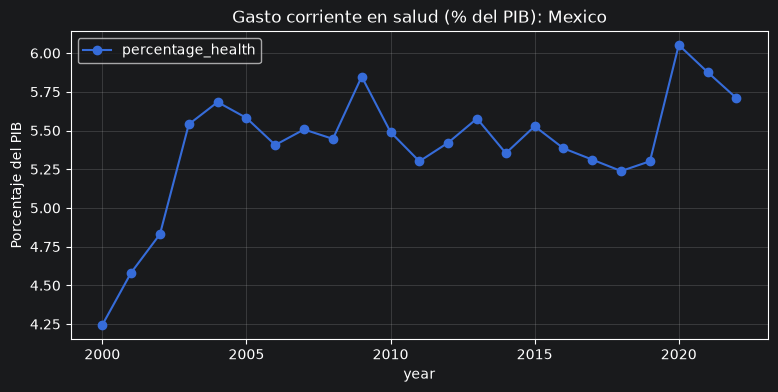

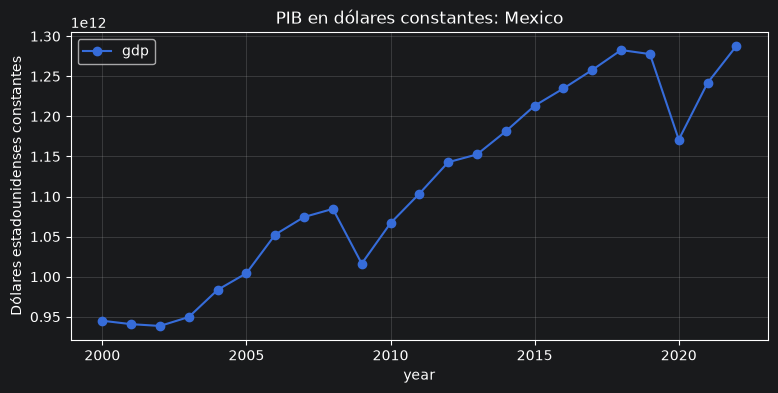

In [19]:
entidad = "Mexico" if "Mexico" in demografia["entity"].values else demografia["entity"].iloc[0]
ejemplo = demografia[demografia["entity"] == entidad].sort_values("year")

ejemplo.plot(x="year", y="percentage_health", marker="o", figsize=(9, 4),
             title=f"Gasto corriente en salud (% del PIB): {entidad}")
plt.ylabel("Porcentaje del PIB")
plt.grid(alpha=0.3)
plt.show()

ejemplo.plot(x="year", y="gdp", marker="o", figsize=(9, 4),
             title=f"PIB en dólares constantes: {entidad}")
plt.ylabel("Dólares estadounidenses constantes")
plt.grid(alpha=0.3)
plt.show()

## 12. Guardar el resultado

El CSV se guarda junto al notebook. Contiene solamente entidades y años compartidos por las seis fuentes y las ocho columnas acordadas.

In [20]:
from pathlib import Path

carpeta_salida = Path("../data/processed")
carpeta_salida.mkdir(parents=True, exist_ok=True)

salida = carpeta_salida / "dataset_owid_2000_2022.csv"
demografia.to_csv(salida, index=False)

print(f"Archivo guardado: {salida.resolve()} | filas: {len(demografia)}")

Archivo guardado: C:\Users\Thomas\Documents\ACAD\bigdata\bigdata_512\U3_1_modelos_ml\data\processed\dataset_owid_2000_2022.csv | filas: 4327
